# Compare Regression Losses with GridSearchCV

Due to its compatibility with the scikit-learn API, `GridSearchCV` can be used to compare `Huber`, `MAE`, and `MSE` losses under a unified pipeline, identify the best loss, and select its optimal hyperparameter.

In [ ]:
## install rehline
%pip install rehline -q

In [2]:
## simulate data
from sklearn.datasets import make_regression

X, y = make_regression(n_samples=10000, n_features=5, noise=30.0, random_state=42)
y = y / y.std()
y[-40:] += 20

In [3]:
## compare Huber, MAE and MSE via GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from rehline import plq_Ridge_Regressor
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings("ignore")

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('reg', plq_Ridge_Regressor(loss={'name': 'mse'}))
])

# Define the parameter grid to search
param_grid = {
    'reg__C': [0.1, 1.0, 10.0],
    'reg__loss': [{'name': 'huber', 'tau': 1.0}, {'name': 'mae'}, {'name': 'mse'}]
}

# Create the GridSearchCV object
grid_search = GridSearchCV(pipe, param_grid, cv=5)
grid_search.fit(X, y)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('reg',
                                        plq_Ridge_Regressor(loss={'name': 'mse'}))]),
             param_grid={'reg__C': [0.1, 1.0, 10.0],
                         'reg__loss': [{'name': 'huber', 'tau': 1.0},
                                       {'name': 'mae'}, {'name': 'mse'}]})

In [4]:
# Print the best loss function and score
print(f"Overall Best Params: {grid_search.best_params_}")
print(f"Overall Best Score:  {grid_search.best_score_:.5f}")

Overall Best Params: {'reg__C': 1.0, 'reg__loss': {'name': 'mae'}}
Overall Best Score:  0.77874


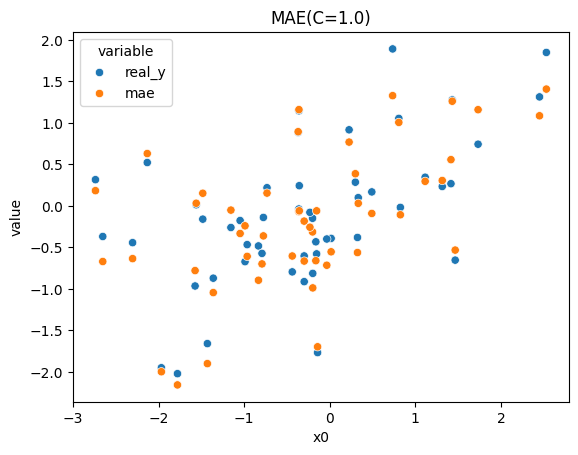

In [5]:
## Plot the best model
import pandas as pd
import seaborn as sns
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", "is_categorical_dtype")
warnings.filterwarnings("ignore", "use_inf_as_na")

n_sample = 50
X_sample, y_sample = X[:n_sample], y[:n_sample]
grid_sample = grid_search.predict(X_sample)

df = pd.DataFrame({'x0': X_sample[:, 0], 'real_y': y_sample, 'mae': grid_sample})
df = df.melt(id_vars='x0')

sns.scatterplot(data=df, x='x0', y='value', hue='variable').set_title("MAE(C=1.0)")
plt.show()

## Compare Huber & MAE & MSE

In [6]:
# Print best results per loss
import pandas as pd
df = pd.DataFrame(grid_search.cv_results_)
df['Loss'] = df['param_reg__loss'].apply(lambda x: x['name'])
df = df.sort_values('mean_test_score', ascending=False)
best = df.drop_duplicates(subset=['Loss'])
table = best[['Loss', 'param_reg__C', 'mean_test_score']].rename(
    columns={'param_reg__C': 'Best C', 'mean_test_score': 'CV Score'}
)

print(table.to_string(index=False))

 Loss  Best C  CV Score
  mae     1.0  0.778740
huber     0.1  0.778691
  mse     0.1  0.769240


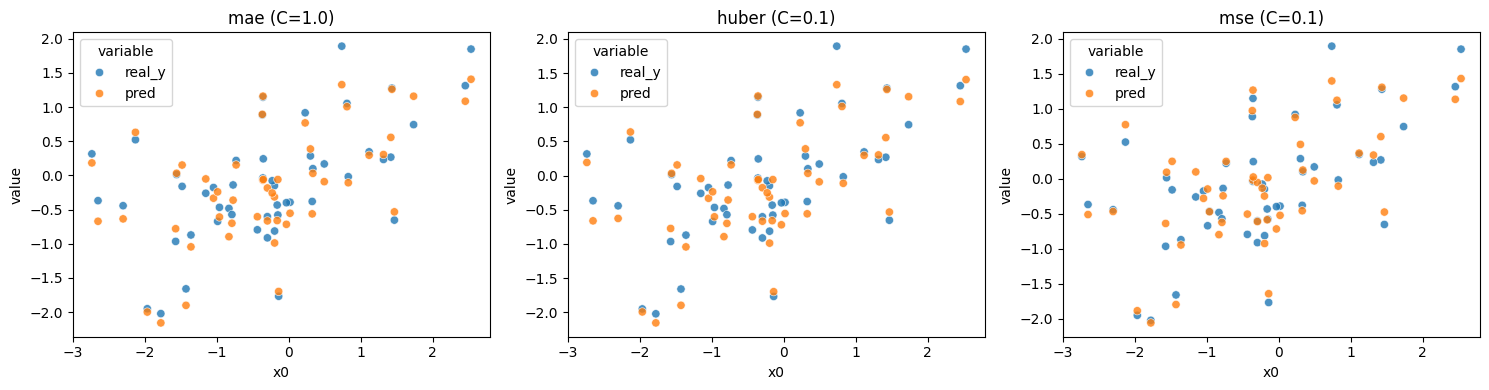

In [7]:
import numpy as np
import seaborn as sns
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore", "is_categorical_dtype")
warnings.filterwarnings("ignore", "use_inf_as_na")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
n_sample = 50
X_sample, y_sample = X[:n_sample], y[:n_sample]

for i in range(len(best)):
    loss = best['Loss'].iloc[i]
    c = best['param_reg__C'].iloc[i]

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('reg', plq_Ridge_Regressor(loss={'name': loss}, C=c))
    ])
    pipe.fit(X, y)

    pred_y = pipe.predict(X_sample)
    df = pd.DataFrame({'x0': X_sample[:,0], 'real_y': y_sample, 'pred': pred_y})
    df = df.melt(id_vars='x0')

    sns.scatterplot(data=df, x='x0', y='value', hue='variable', ax=axes[i], alpha=0.8).set_title(f"{loss} (C={c})")

plt.tight_layout()
plt.show()